In [32]:
from rocketpy import Environment, SolidMotor, Rocket, Flight


Gravity Details

Acceleration of gravity at surface level:    9.7860 m/s²
Acceleration of gravity at   8.000 km (ASL): 9.7629 m/s²


Launch Site Details

Launch Date: 2026-07-29 12:00:00 UTC
Launch Site Latitude: -21.90000°
Launch Site Longitude: -48.96000°
Reference Datum: SIRGAS2000
Launch Site UTM coordinates: 90722.70 W    7572960.38 S
Launch Site UTM zone: 23K
Launch Site Surface Elevation: 495.0 m


Atmospheric Model Details

Atmospheric Model Type: custom_atmosphere
custom_atmosphere Maximum Height: 8.000 km

Surface Atmospheric Conditions

Surface Wind Speed: 4.63 m/s
Surface Wind Direction: 18.34°
Surface Wind Heading: 198.34°
Surface Pressure: 955.47 hPa
Surface Temperature: 284.94 K
Surface Air Density: 1.168 kg/m³
Surface Speed of Sound: 338.26 m/s


Earth Model Details

Earth Radius at Launch site: 6375.18 km
Semi-major Axis: 6378.14 km
Semi-minor Axis: 6356.75 km
Flattening: 0.0034


Atmospheric Model Plots



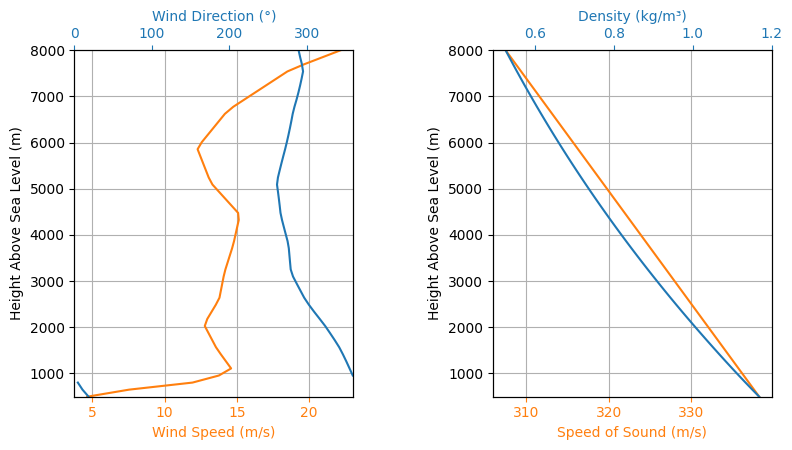

In [33]:
# Standard libraries
import datetime
import math
import numpy as np
import matplotlib.pyplot as plt

# RocketPy
from rocketpy import (
    Environment,
    SolidMotor,
    Rocket,
    Flight,
)

# Date for weather forecast
tomorrow = datetime.date.today() + datetime.timedelta(days=1)

env_forecast = Environment(
    latitude=-21.90,
    longitude=-48.96156,
    elevation=495
)

env_forecast.set_date(
    (tomorrow.year, tomorrow.month, tomorrow.day, 12)
)

env_forecast.set_atmospheric_model(
    type="Forecast",
    file="GFS"
)

env = Environment(
    latitude=-21.90,
    longitude=-48.96,
    elevation=495
)

env.set_date(
    (tomorrow.year, tomorrow.month, tomorrow.day, 12)
)

env.set_atmospheric_model(
    type="custom_atmosphere",
    wind_u=env_forecast.wind_velocity_x,
    wind_v=env_forecast.wind_velocity_y,
)

env.max_expected_height = 8000
env.info()

In [34]:
Airavata = SolidMotor(
    thrust_source= r"C:\Users\anitr\Openrocket\engine\LASC_Static2_K454 - Copy.eng",
    dry_mass=1.36,
    dry_inertia=(0.03, 0.03, 0.0008),
    nozzle_radius=32 / 1000,
    grain_number=4,
    grain_density=1700,
    grain_outer_radius=27 / 1000,
    grain_initial_inner_radius=8.25 / 1000,
    grain_initial_height=85 / 1000,
    grain_separation=0,
    grains_center_of_mass_position=0.242,
    center_of_dry_mass_position=0.212,
    nozzle_position=-0.036,
    burn_time=3.288,
    throat_radius=11.5 / 1000,
    coordinate_system_orientation="nozzle_to_combustion_chamber",
)

Nozzle Details
Nozzle Radius: 0.032 m
Nozzle Throat Radius: 0.0115 m

Grain Details
Number of Grains: 4
Grain Spacing: 0 m
Grain Density: 1700 kg/m3
Grain Outer Radius: 0.027 m
Grain Inner Radius: 0.00825 m
Grain Height: 0.085 m
Grain Volume: 0.000 m3
Grain Mass: 0.300 kg

Motor Details
Total Burning Time: 3.288 s
Total Propellant Mass: 1.200 kg
Structural Mass Ratio: 0.531
Average Propellant Exhaust Velocity: 1097.803 m/s
Average Thrust: 400.711 N
Maximum Thrust: 1045.289 N at 1.509 s after ignition.
Total Impulse: 1317.536 Ns



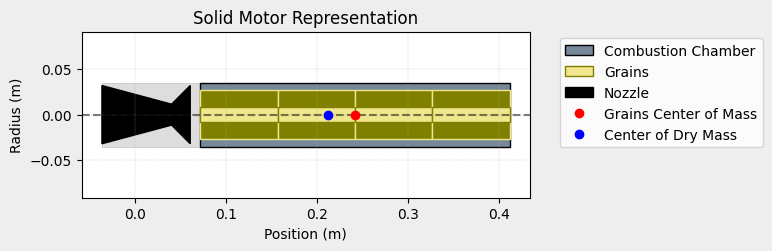

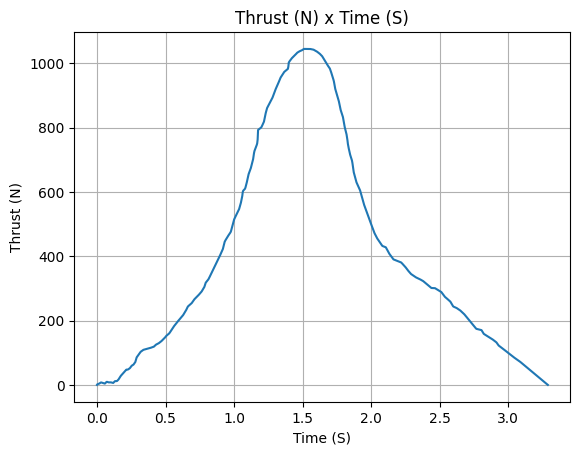

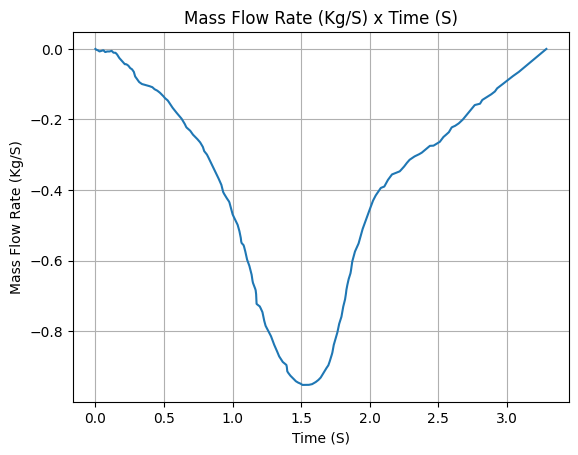

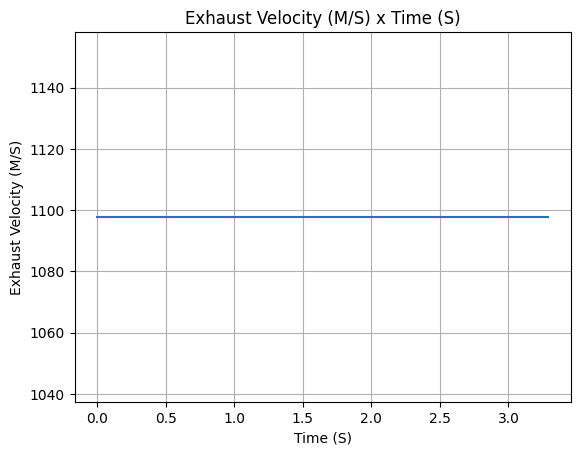

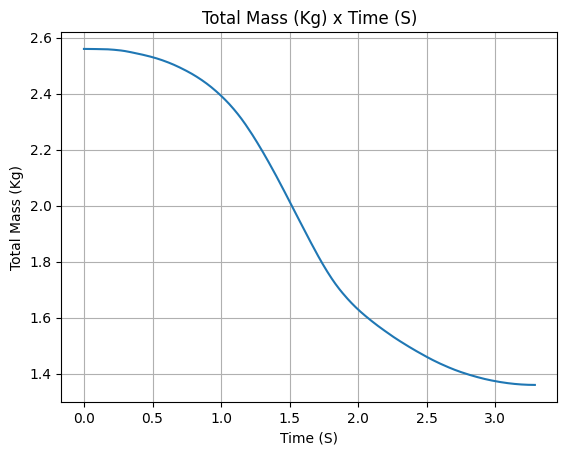

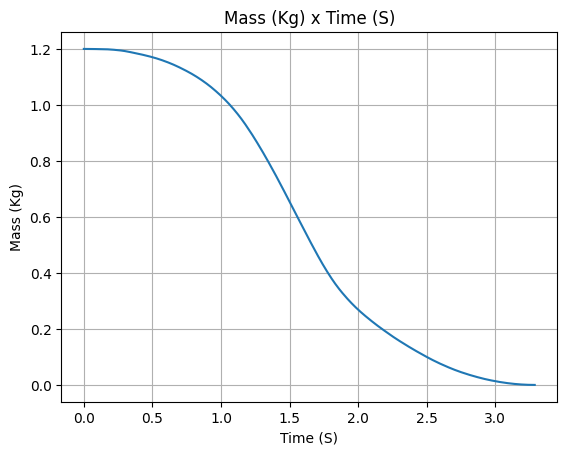

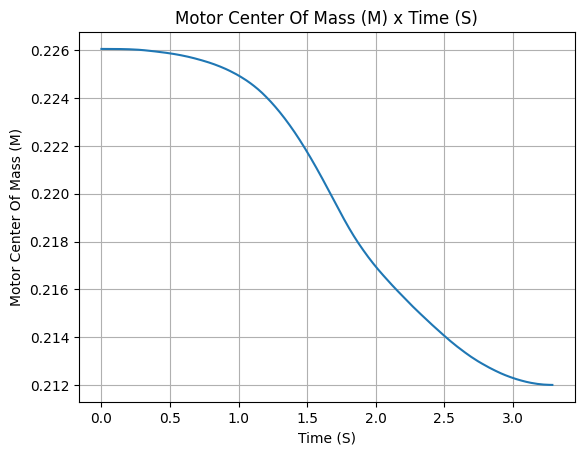

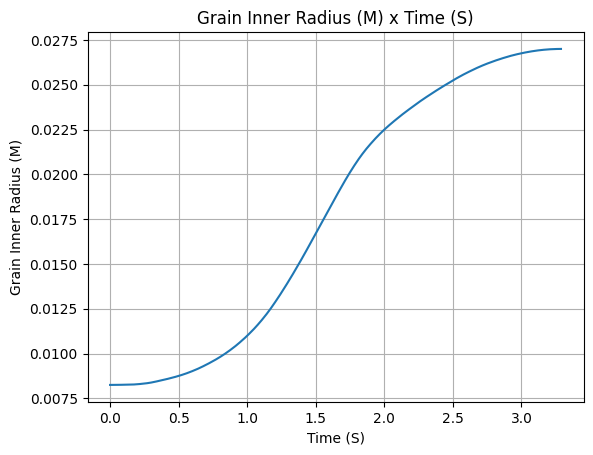

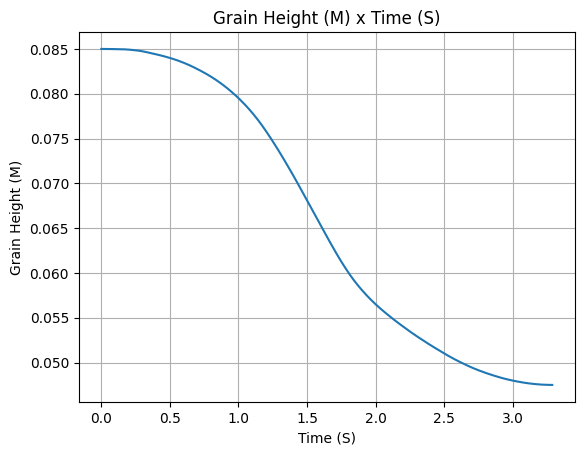

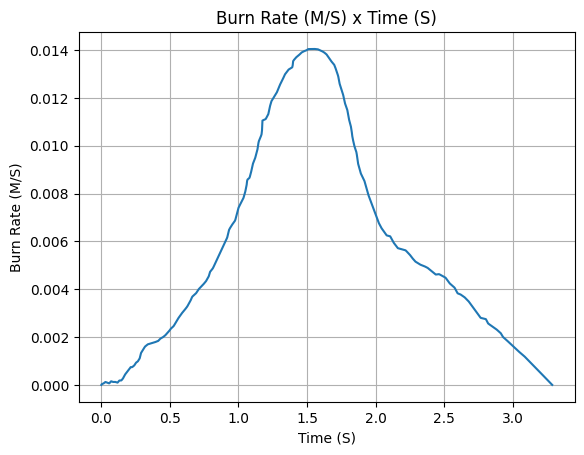

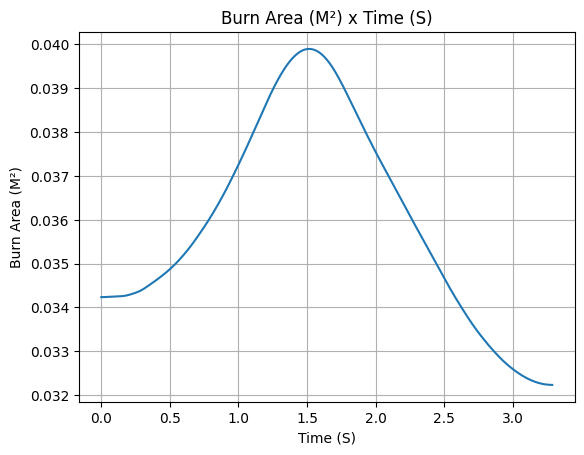

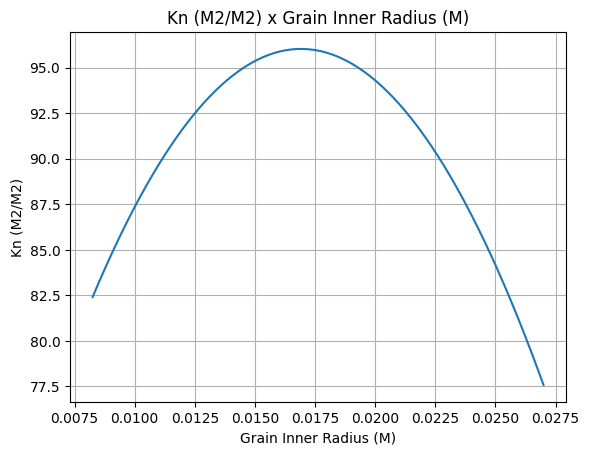

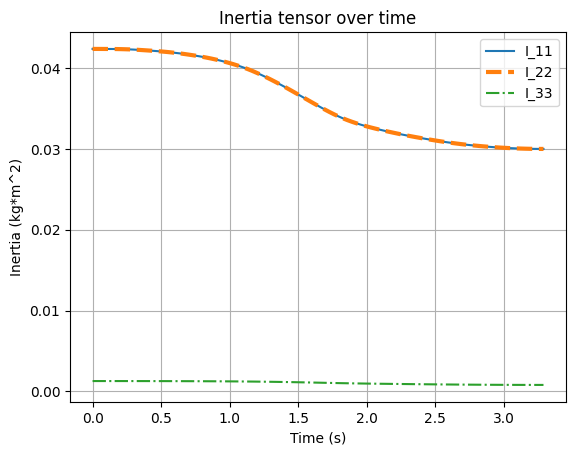

In [35]:
Airavata.all_info()

In [36]:
payload_mass = 1.070  # in kg
rocket_mass = 5.268- payload_mass  # in kg

print(
    "Rocket Mass Without Motor: {:.4} kg (with Payload)".format(
        rocket_mass + payload_mass
    )
)
print("Loaded Motor Mass: {:.4} kg".format(Airavata.total_mass(0)))
print("Payload Mass: {:.4} kg".format(payload_mass))
print(
    "Fully loaded Rocket Mass: {:.4} kg".format(
        rocket_mass + Airavata.total_mass(0) + payload_mass
    )
)


Rocket Mass Without Motor: 5.268 kg (with Payload)
Loaded Motor Mass: 2.56 kg
Payload Mass: 1.07 kg
Fully loaded Rocket Mass: 7.828 kg


In [37]:
Garuda = Rocket(
    radius=0.0570,
    mass=rocket_mass + payload_mass,
    inertia=(1.341,1.341,0.010),
    power_off_drag=r"d:\LASC GARUDA\rocketpy csv\rocketpy csv\CD off garuda.CSV",
    power_on_drag=r"D:\LASC GARUDA\rocketpy csv\rocketpy csv\CD on garuda.CSV",
    center_of_mass_without_motor=0.88,
    coordinate_system_orientation="tail_to_nose",
)

Garuda.add_motor(Airavata, position=0)



Garuda.set_rail_buttons(
    upper_button_position=0.63,
    lower_button_position=0.12,
    angular_position=45,
)

Garuda.add_nose(length=0.3, kind="von karman", position=1.86)

Garuda.add_trapezoidal_fins(
    n=4,
    root_chord=0.120,
    tip_chord=0.080,
    span=0.090,
    sweep_length=0.055,
    position=0.12,
    cant_angle=0,
)


In [38]:
Garuda.info()



Inertia Details

Rocket Mass: 5.268 kg (without motor)
Rocket Dry Mass: 6.628 kg (with unloaded motor)
Rocket Loaded Mass: 7.828 kg
Rocket Structural Mass Ratio: 0.847
Rocket Inertia (with unloaded motor) 11: 1.853 kg*m2
Rocket Inertia (with unloaded motor) 22: 1.853 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.011 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.057 m
Rocket Frontal Area: 0.010207 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.137 m
Rocket Center of Dry Mass - Nozzle Exit: 0.779 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.501 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.077 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 5.790/rad

Center of Pressure

Nose Co

In [39]:
flight_Garuda = Flight(
    rocket=Garuda,
    environment=env,
    rail_length=4,
    inclination=80,
    heading=90,
    terminate_on_apogee=True,
    name="Rocket Flight Garuda",
)

In [40]:
Garuda_without_payload = Rocket(
    radius=0.0570,
    mass=3.831,
    inertia=(0.652,0.652,0.009),
    power_off_drag=r"D:\LASC GARUDA\CD_power_off_merged body.csv",
    power_on_drag=r"D:\LASC GARUDA\CD_power_on_merged body.csv",
    center_of_mass_without_motor=0.669,
    coordinate_system_orientation="tail_to_nose",
)

In [41]:
#main = Garuda_without_payload.add_parachute(
    #name="Main",
    #cd_s=2.3682,
    #trigger="apogee",          # deployment altitude (change if your flight computer uses another logic)
    #sampling_rate=100,
    #lag=1.5,
    #noise=(0, 8.3, 0.5),
#)

In [42]:
Garuda_without_payload.info()


Inertia Details

Rocket Mass: 3.831 kg (without motor)
Rocket Dry Mass: 3.831 kg (with unloaded motor)
Rocket Loaded Mass: 3.831 kg
Rocket Structural Mass Ratio: 1.000
Rocket Inertia (with unloaded motor) 11: 0.652 kg*m2
Rocket Inertia (with unloaded motor) 22: 0.652 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.009 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.057 m
Rocket Frontal Area: 0.010207 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.000 m
Rocket Center of Dry Mass - Nozzle Exit: 0.669 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.669 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.000 m


Aerodynamics Lift Coefficient Derivatives


Center of Pressure


Stability

Center of Mass position (time=0): 0.669 m
Center of Pressure position (time=0): 0.000 m


In [43]:
payload_Garuda = Rocket(
    radius=114 / 2000,
    mass=1.070,
    inertia= (0.027 ,0.027 , 0.001),
    power_off_drag=r"d:\LASC GARUDA\CD off payload final.CSV",
    power_on_drag=r"D:\LASC GARUDA\CD on payload final.CSV",
    center_of_mass_without_motor=0.2,
)
#payload_main = payload_Garuda.add_parachute(
    #name="Payload",
    #cd_s=0.4954,
    #trigger="apogee",
    #sampling_rate=105,
    #lag=0,
    #noise=(0, 8.3, 0.5),
#)

In [44]:
payload_flight = Flight(
    rocket=payload_Garuda,
    environment=env,
    rail_length=4,  # does not matter since the flight is starting at apogee
    inclination=0,
    heading=0,
    initial_solution=flight_Garuda,
    name="PayloadFlight",
)

In [45]:
flight_without_payload = Flight(
    rocket=Garuda_without_payload,
    environment=env,
    rail_length=4,  # does not matter since the flight is starting at apogee
    inclination=0,
    heading=0,
    initial_solution=flight_Garuda,
    name="Rocket Flight Without Payload",
)

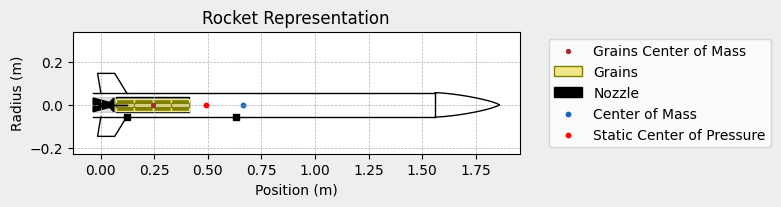

In [46]:
Garuda.draw()

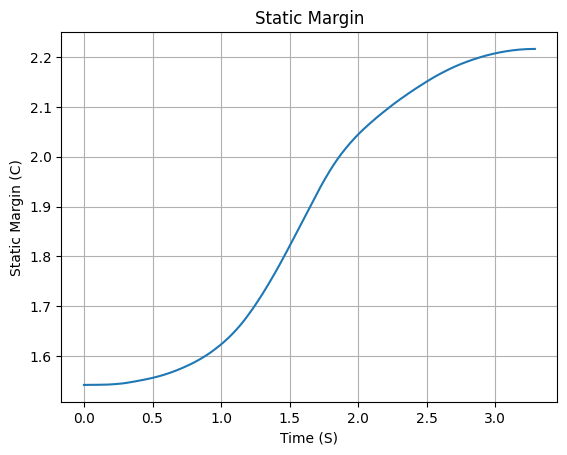

In [47]:
Garuda.plots.static_margin()

In [48]:
from rocketpy.plots.compare import CompareFlights

In [49]:
comparison = CompareFlights(
    [flight_Garuda, flight_without_payload, payload_flight]
)

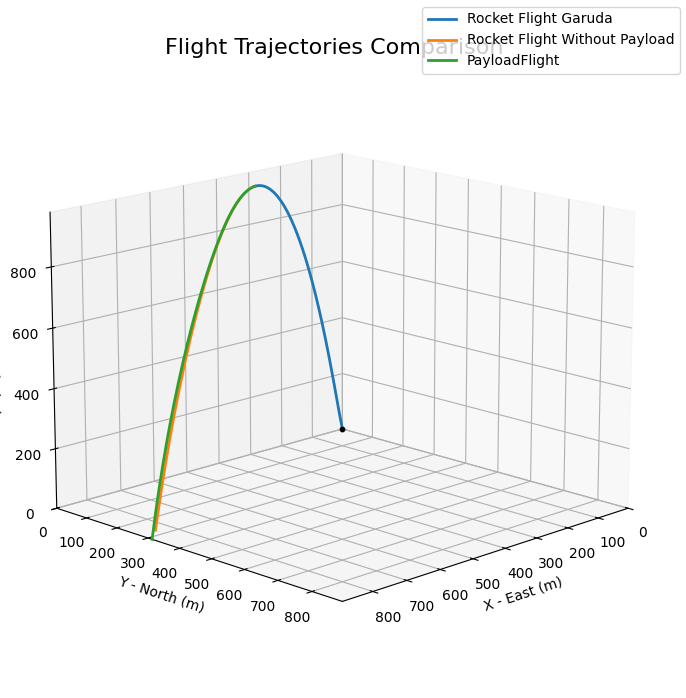

In [50]:
comparison.trajectories_3d(legend=True)

In [51]:
print("Launch elevation:", env.elevation)
print("Apogee (ASL):", flight_Garuda.apogee)
print("Height above launch:", flight_Garuda.apogee - env.elevation)

Launch elevation: 495
Apogee (ASL): 1472.378030035571
Height above launch: 977.3780300355711


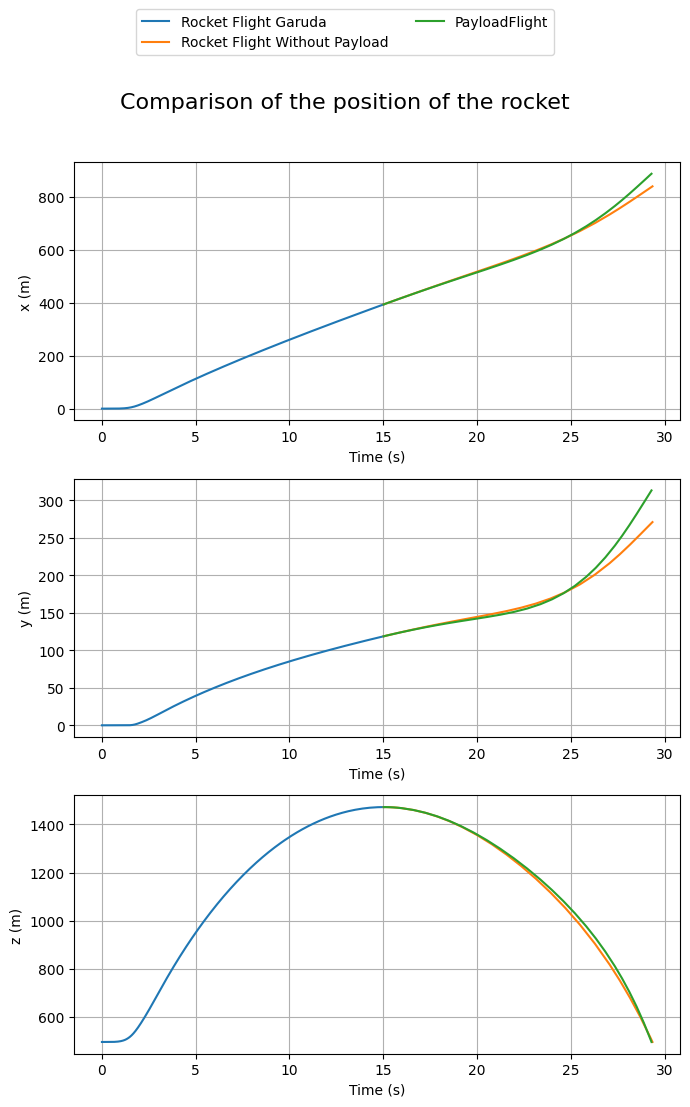

In [52]:
comparison.positions()


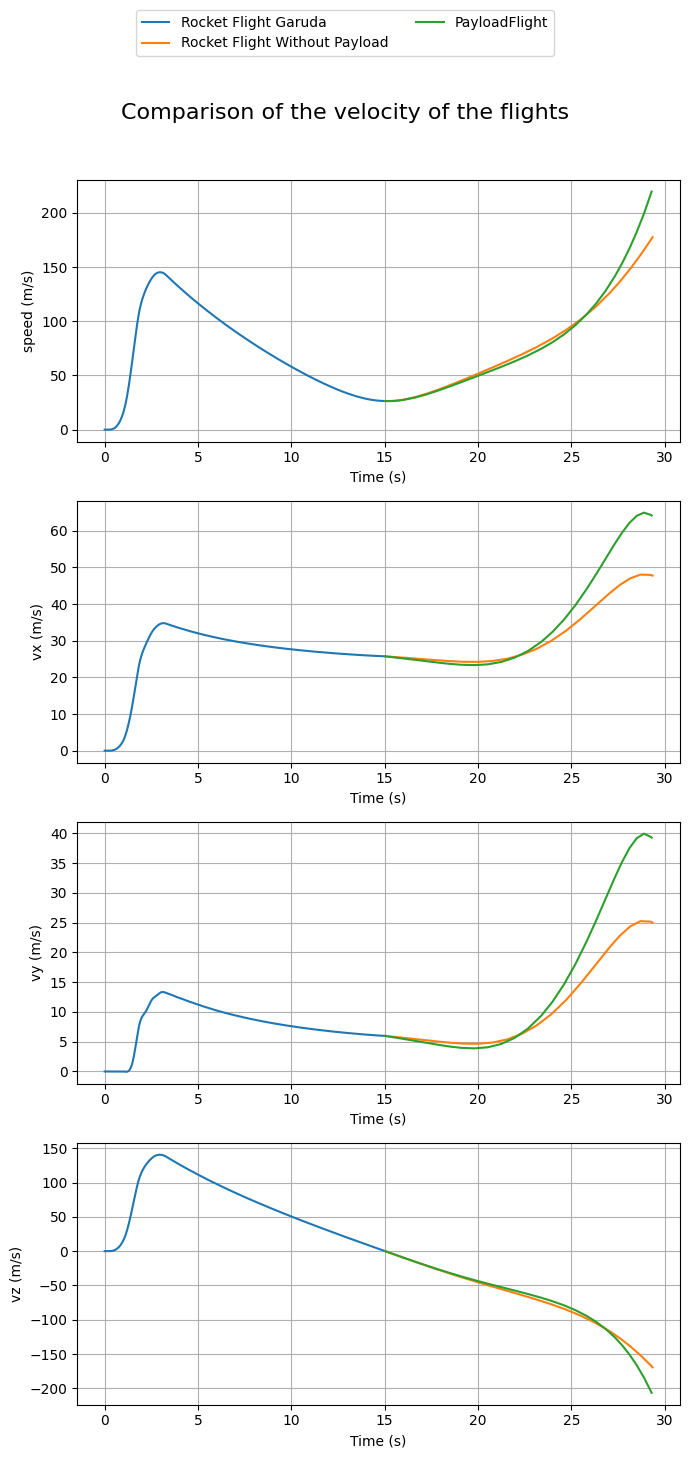

In [53]:
comparison.velocities()

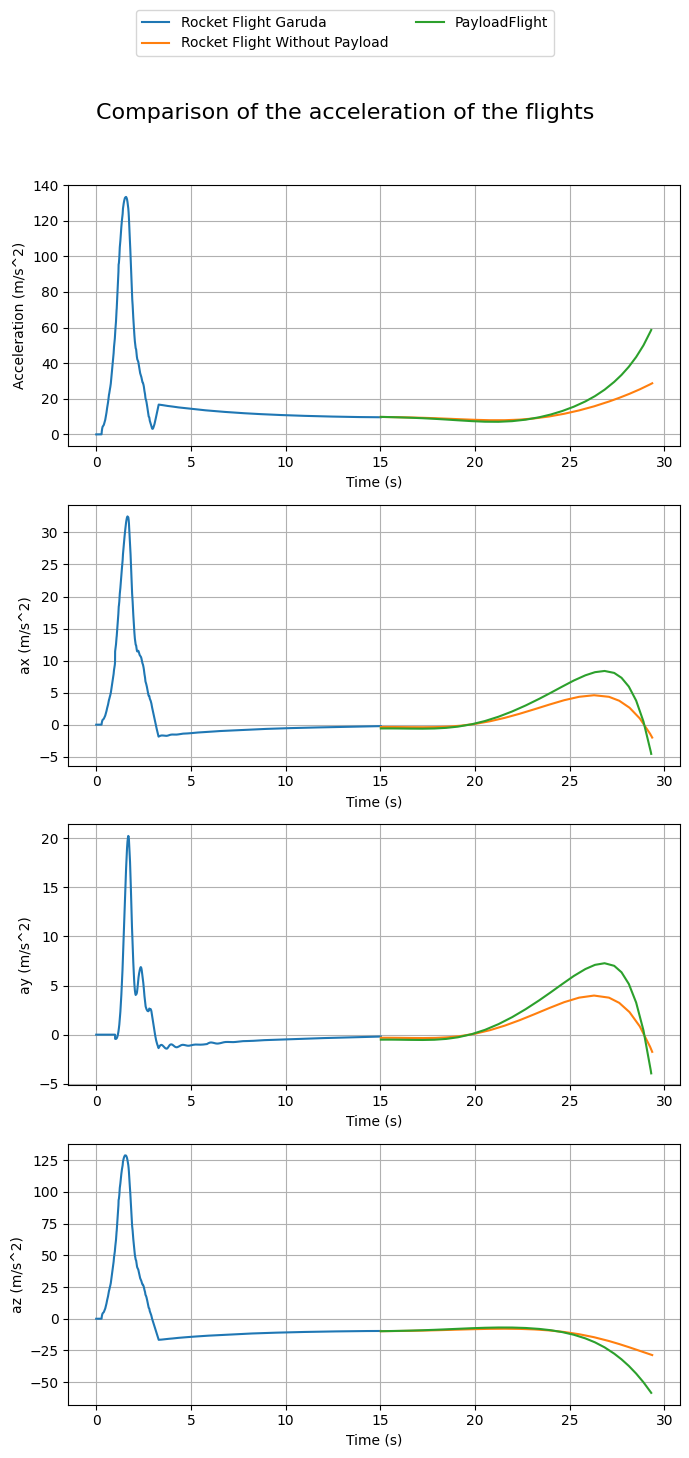

In [54]:
comparison.accelerations()

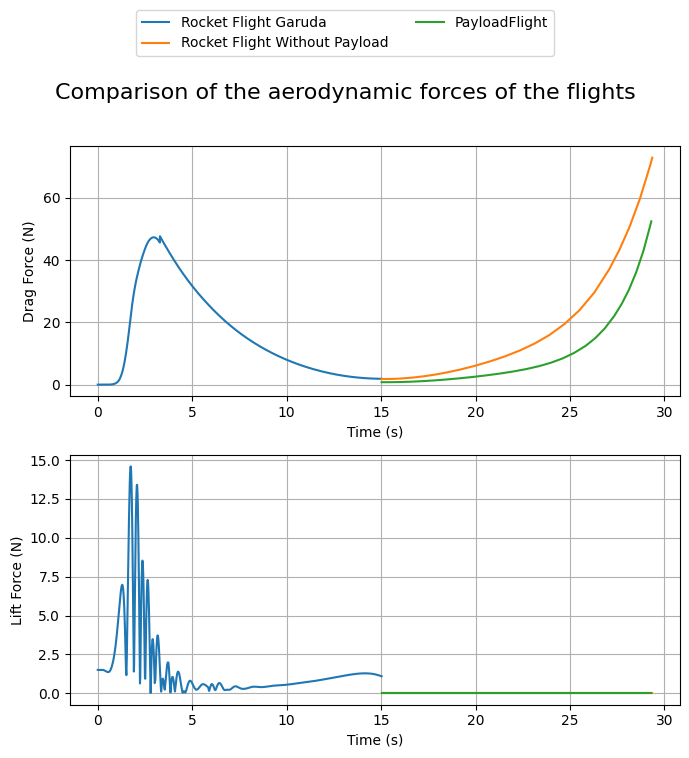

In [55]:
comparison.aerodynamic_forces()

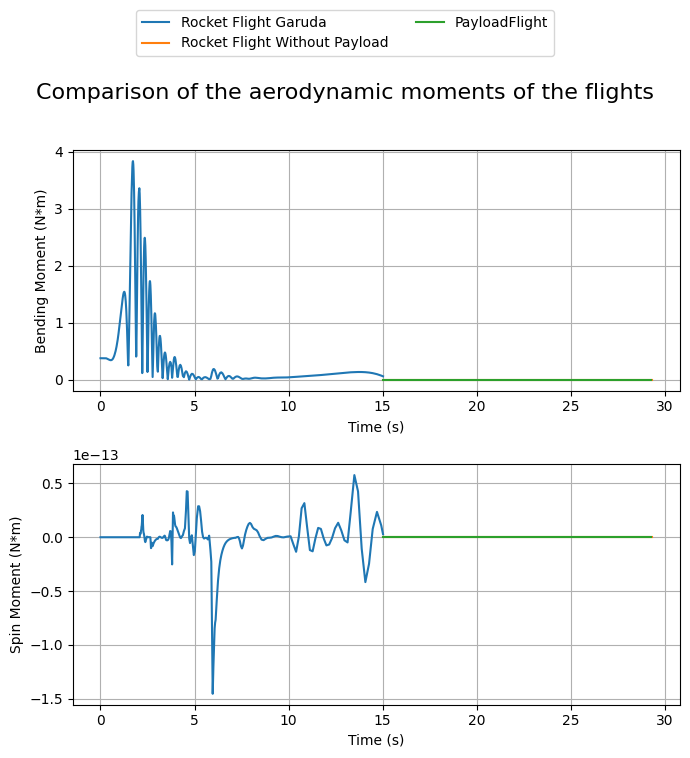

In [56]:
comparison.aerodynamic_moments()

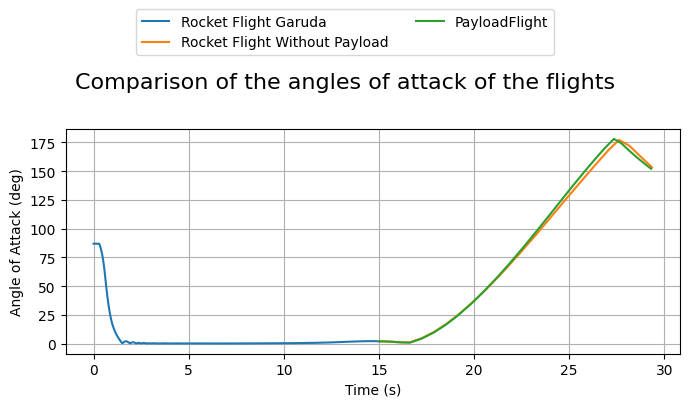

In [57]:
comparison.angles_of_attack()

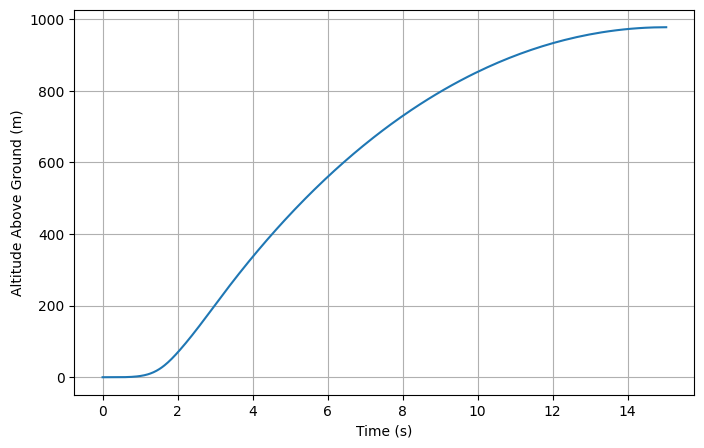

In [58]:
import matplotlib.pyplot as plt

t = flight_Garuda.z[:, 0]
z_agl = flight_Garuda.z[:, 1] - env.elevation

plt.figure(figsize=(8,5))
plt.plot(t, z_agl)
plt.xlabel("Time (s)")
plt.ylabel("Altitude Above Ground (m)")
plt.grid(True)
plt.show()

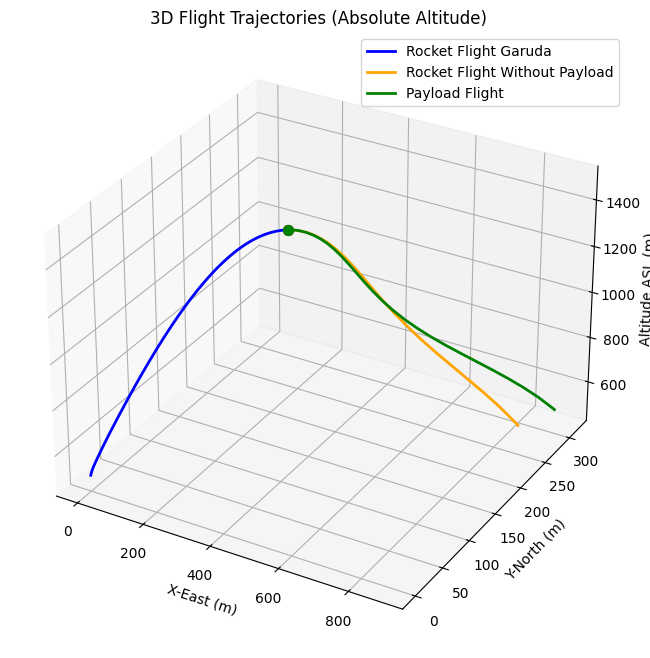

In [59]:
import matplotlib.pyplot as plt

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection="3d")

flights = [
    ("Rocket Flight Garuda", flight_Garuda, "blue"),
    ("Rocket Flight Without Payload", flight_without_payload, "orange"),
    ("Payload Flight", payload_flight, "green"),
]

for name, flight, color in flights:

    ax.plot(
        flight.x[:,1],
        flight.y[:,1],
        flight.z[:,1],
        color=color,
        linewidth=2,
        label=name
    )

    t = flight.apogee_time

    ax.scatter(
        flight.x(t),
        flight.y(t),
        flight.z(t),
        color=color,
        s=50
    )

ax.set_xlabel("X-East (m)")
ax.set_ylabel("Y-North (m)")
ax.set_zlabel("Altitude ASL (m)")
ax.set_title("3D Flight Trajectories (Absolute Altitude)")
ax.legend()

plt.show()


Inertia Details

Rocket Mass: 5.268 kg (without motor)
Rocket Dry Mass: 6.628 kg (with unloaded motor)
Rocket Loaded Mass: 7.828 kg
Rocket Structural Mass Ratio: 0.847
Rocket Inertia (with unloaded motor) 11: 1.853 kg*m2
Rocket Inertia (with unloaded motor) 22: 1.853 kg*m2
Rocket Inertia (with unloaded motor) 33: 0.011 kg*m2
Rocket Inertia (with unloaded motor) 12: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 13: 0.000 kg*m2
Rocket Inertia (with unloaded motor) 23: 0.000 kg*m2

Geometrical Parameters

Rocket Maximum Radius: 0.057 m
Rocket Frontal Area: 0.010207 m2

Rocket Distances
Rocket Center of Dry Mass - Center of Mass without Motor: 0.137 m
Rocket Center of Dry Mass - Nozzle Exit: 0.779 m
Rocket Center of Dry Mass - Center of Propellant Mass: 0.501 m
Rocket Center of Mass - Rocket Loaded Center of Mass: 0.077 m


Aerodynamics Lift Coefficient Derivatives

Nose Cone Lift Coefficient Derivative: 2.000/rad
Fins Lift Coefficient Derivative: 5.790/rad

Center of Pressure

Nose Co

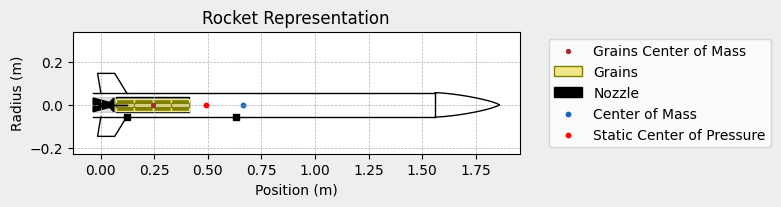


Mass Plots
----------------------------------------


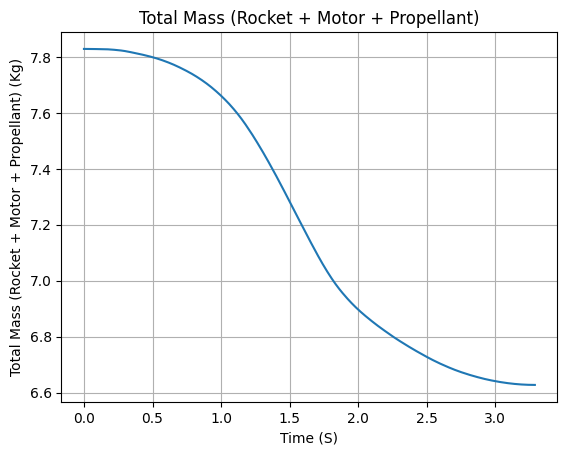

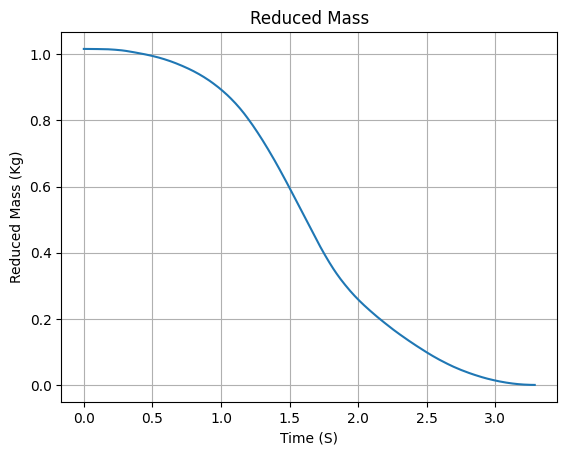


Aerodynamics Plots
----------------------------------------
Drag Plots
--------------------


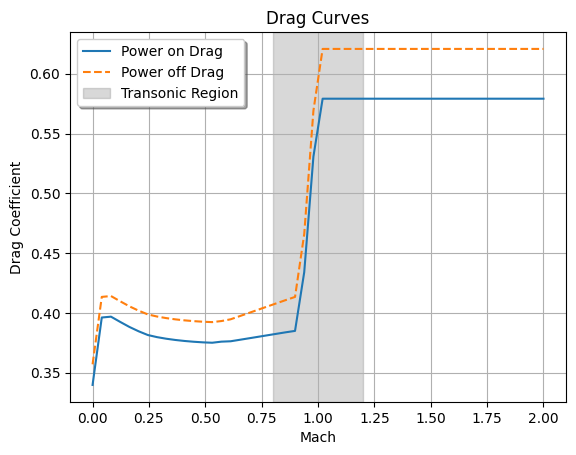


Stability Plots
--------------------


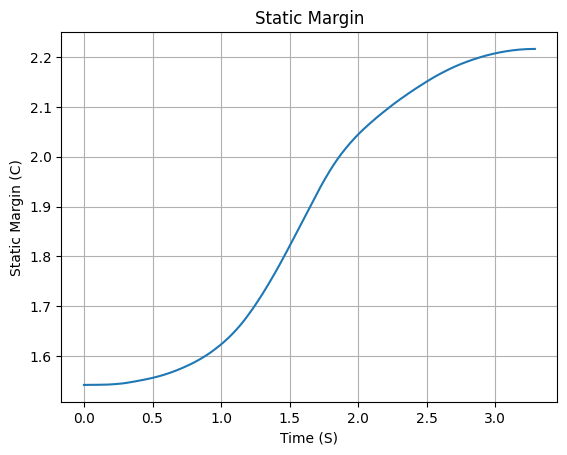

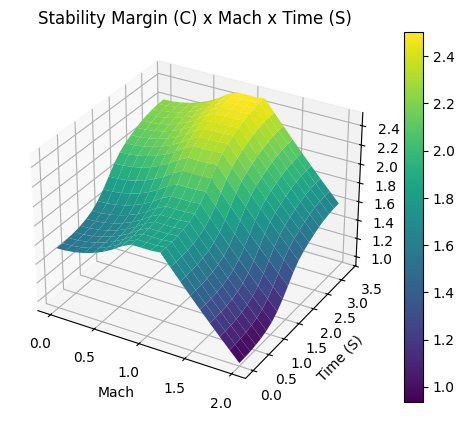


Thrust-to-Weight Plot
----------------------------------------


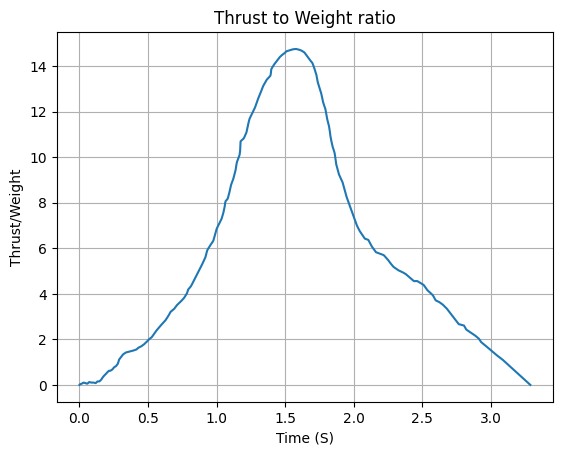

In [60]:
Garuda.all_info()

In [61]:
print(payload_flight.parachute_events)

[]


In [62]:
print(payload_flight.impact_velocity)

-206.5042124054379
